# Alumnos: Leila Saker, Matias Garcia, Paola Ciares, Ramiro Barone

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm

Cargamos los datos de entrenamiento que vamos a utilizar para generar nuestro modelo, y analizamos su contenido

In [ ]:
df_train = pd.read_csv('diabetes_prediction_dataset_train-labeled.csv')
df_train

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,20432,Male,4.0,0,0,never,19.28,3.5,155,0
1,49682,Female,50.0,0,0,former,27.32,5.7,159,0
2,73886,Female,43.0,0,0,never,21.54,4.5,145,0
3,53144,Male,64.0,0,0,current,28.22,6.0,130,0
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140,0
...,...,...,...,...,...,...,...,...,...,...
94995,81090,Female,56.0,0,0,never,22.30,6.2,158,0
94996,90924,Female,24.0,0,0,never,22.50,6.1,126,0
94997,64600,Female,32.0,0,0,never,24.92,6.6,145,0
94998,96132,Female,21.0,0,0,current,20.59,4.5,155,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              95000 non-null  int64  
 1   gender               95000 non-null  object 
 2   age                  95000 non-null  float64
 3   hypertension         95000 non-null  int64  
 4   heart_disease        95000 non-null  int64  
 5   smoking_history      95000 non-null  object 
 6   bmi                  95000 non-null  float64
 7   HbA1c_level          95000 non-null  float64
 8   blood_glucose_level  95000 non-null  int64  
 9   diabetes             95000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 7.2+ MB


In [ ]:
df_train.describe()

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000
mean,50016.501389,41.935269,0.075074,0.039463,27.320879,5.527659,138.070537,0.085074
std,28868.357071,22.514788,0.263512,0.194695,6.626335,1.070261,40.739962,0.278993
min,1.000000,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,25021.750000,24.000000,0.000000,0.000000,23.650000,4.800000,100.000000,0.000000
50%,50024.000000,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,75024.250000,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,100000.000000,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


Cargamos los datos de test, y analizamos su contenido. Podemos ver que la columna `diabetes` no contiene datos, ya que es lo que debemos predecir

In [ ]:
df_test = pd.read_csv('diabetes_prediction_dataset_test.csv')
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              5000 non-null   int64  
 1   gender               5000 non-null   object 
 2   age                  5000 non-null   float64
 3   hypertension         5000 non-null   int64  
 4   heart_disease        5000 non-null   int64  
 5   smoking_history      5000 non-null   object 
 6   bmi                  5000 non-null   float64
 7   HbA1c_level          5000 non-null   float64
 8   blood_glucose_level  5000 non-null   int64  
 9   diabetes             0 non-null      float64
dtypes: float64(4), int64(4), object(2)
memory usage: 390.8+ KB


# Análisis estadístico de los datos

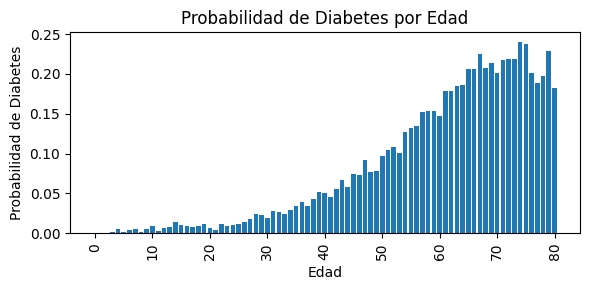

In [ ]:
diabetes_by_age = df_train.groupby('age')['diabetes'].mean()

plt.figure(figsize=(6, 3))
plt.bar(diabetes_by_age.index, diabetes_by_age.values)

plt.xlabel('Edad')
plt.ylabel('Probabilidad de Diabetes')
plt.title('Probabilidad de Diabetes por Edad')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

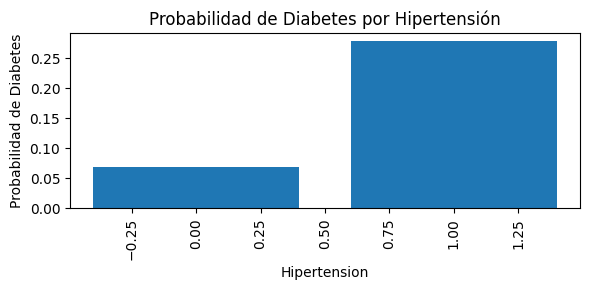

In [ ]:
diabetes_by_hypertension = df_train.groupby('hypertension')['diabetes'].mean()

# Create the bar chart
plt.figure(figsize=(6, 3)) # Adjust figure size as needed
plt.bar(diabetes_by_hypertension.index, diabetes_by_hypertension.values)

plt.xlabel('Hipertension')
plt.ylabel('Probabilidad de Diabetes')
plt.title('Probabilidad de Diabetes por Hipertensión')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Probabilidad de Diabetes por enfermedad cardíaca'}, xlabel='Heart Desease', ylabel='Diabetes'>

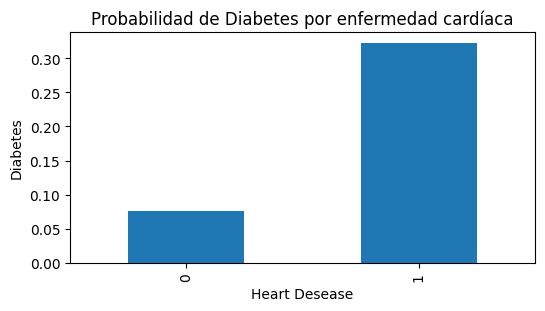

In [ ]:
df_train.groupby("heart_disease").diabetes.mean().plot(kind='bar', xlabel="Heart Desease", ylabel="Diabetes", title='Probabilidad de Diabetes por enfermedad cardíaca', figsize=(6, 3))

<Axes: xlabel='diabetes'>

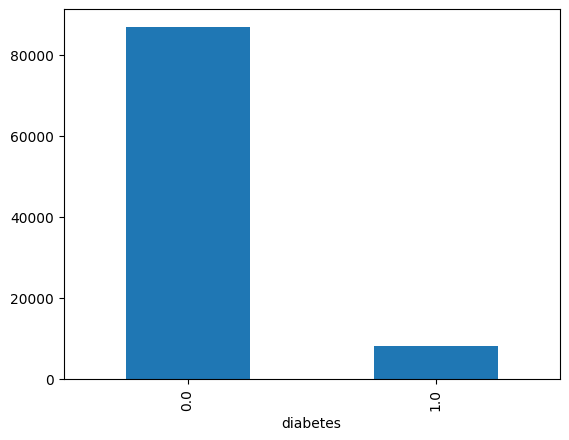

In [ ]:
df_train.groupby("patient").diabetes.mean().value_counts().plot(kind='bar')

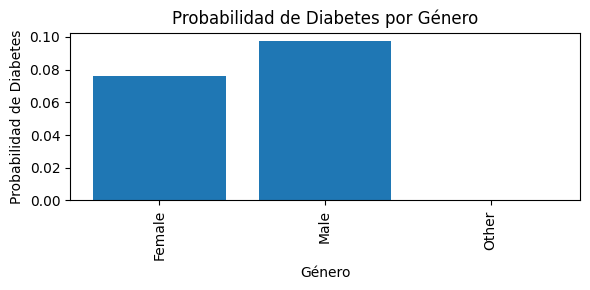

In [ ]:
diabetes_by_gender = df_train.groupby('gender')['diabetes'].mean()

# create the bar chart
plt.figure(figsize=(6, 3))
plt.bar(diabetes_by_gender.index, diabetes_by_gender.values)

plt.xlabel('Género')
plt.ylabel('Probabilidad de Diabetes')
plt.title('Probabilidad de Diabetes por Género')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

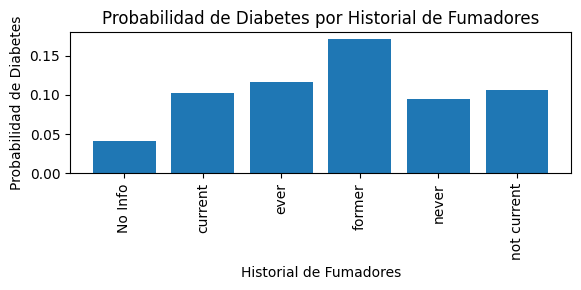

In [ ]:
diabetes_by_smoking_history = df_train.groupby('smoking_history')['diabetes'].mean()

plt.figure(figsize=(6, 3))
plt.bar(diabetes_by_smoking_history.index, diabetes_by_smoking_history.values)

plt.xlabel('Historial de Fumadores')
plt.ylabel('Probabilidad de Diabetes')
plt.title('Probabilidad de Diabetes por Historial de Fumadores')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

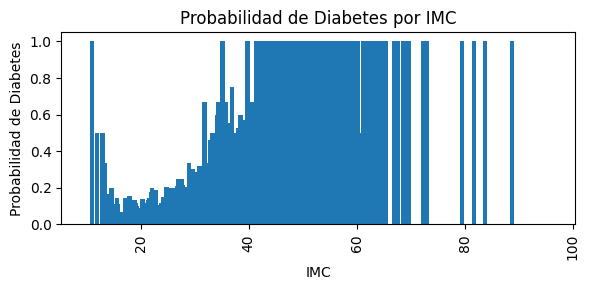

In [ ]:
diabetes_by_bmi = df_train.groupby('bmi')['diabetes'].mean()

plt.figure(figsize=(6, 3))
plt.bar(diabetes_by_bmi.index, diabetes_by_bmi.values)

plt.xlabel('IMC')
plt.ylabel('Probabilidad de Diabetes')
plt.title('Probabilidad de Diabetes por IMC')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

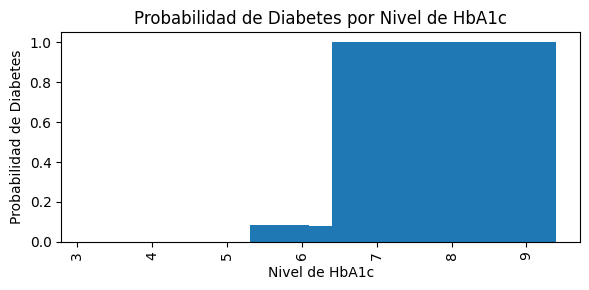

In [ ]:
diabetes_by_HbA1c_level = df_train.groupby('HbA1c_level')['diabetes'].mean()

plt.figure(figsize=(6, 3))
plt.bar(diabetes_by_HbA1c_level.index, diabetes_by_HbA1c_level.values)

plt.xlabel('Nivel de HbA1c')
plt.ylabel('Probabilidad de Diabetes')
plt.title('Probabilidad de Diabetes por Nivel de HbA1c')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

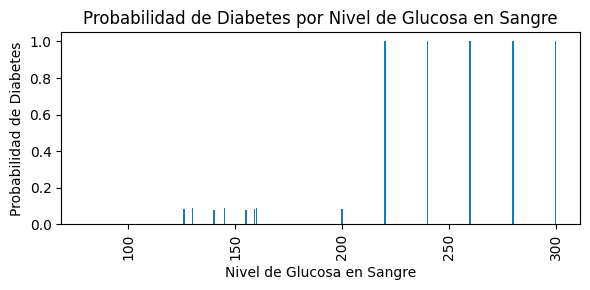

In [ ]:
diabetes_by_blood_glucose_level = df_train.groupby('blood_glucose_level')['diabetes'].mean()

plt.figure(figsize=(6, 3))
plt.bar(diabetes_by_blood_glucose_level.index, diabetes_by_blood_glucose_level.values)

plt.xlabel('Nivel de Glucosa en Sangre')
plt.ylabel('Probabilidad de Diabetes')
plt.title('Probabilidad de Diabetes por Nivel de Glucosa en Sangre')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

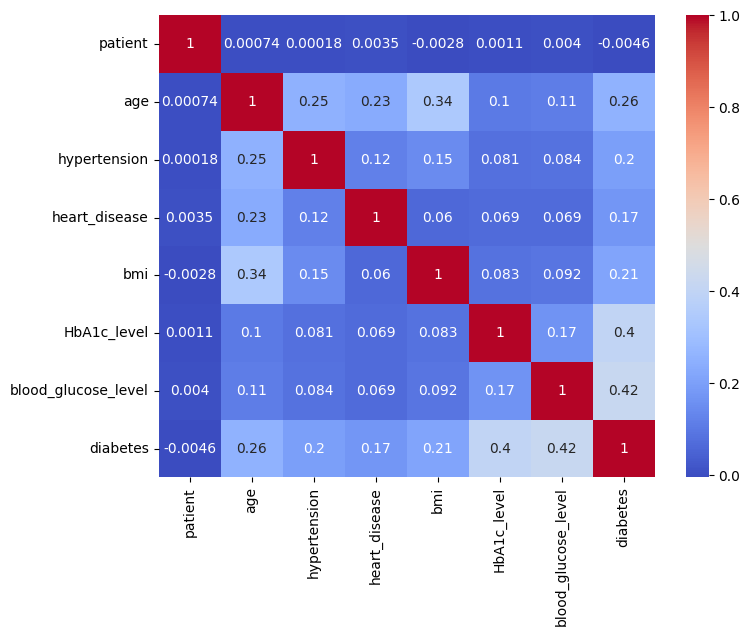

In [ ]:
dt_numerics = df_train.select_dtypes(include=np.number)
dt_numerics.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(dt_numerics.corr(), annot=True, cmap='coolwarm')
plt.show()

Los gráficos sugieren lo siguiente:

*   La probabilidad de tener diabetes parece aumentar con: la edad, hipertensión, enfermedad cardíaca, IMC,  Nivel de HbA1c y nivel de glucosa en sangre.
*   Parece haber una pequeña diferencia en la probabilidad de diabetes entre los géneros representados en el conjunto de datos, siendo el género masculino ligeramente más propenso que los otros.

*   El mapa de calor muestra una correlación positiva entre diabetes y blood_glucose_level, HbA1c_level, age y bmi.

En resumen, los gráficos sugieren que la edad, la hipertensión, la enfermedad cardíaca, el IMC, el nivel de HbA1c y el nivel de glucosa en sangre son factores importantes que influyen en la probabilidad de tener diabetes. Los niveles de HbA1c y glucosa en sangre, en particular, muestran las correlaciones más fuertes con la diabetes. El historial de fumadores también parece tener alguna influencia, mientras que el género parece ser menos predictivo.

# Transformamos las variables que son categoricas a númericas y agregamos las nuevas columnas al dataset

In [ ]:
columnsToEncoder= df_train[['gender','smoking_history']]

encoder = OneHotEncoder(sparse_output=False)
encoded_columns = encoder.fit_transform(columnsToEncoder)


In [ ]:
columnsToEncoderTest = df_test[['gender','smoking_history']]
encoderTest = OneHotEncoder(sparse_output=False)
encoded_columns_test = encoderTest.fit_transform(columnsToEncoderTest)

encoded_df_test = pd.DataFrame(encoded_columns_test, columns=encoderTest.get_feature_names_out(columnsToEncoderTest.columns))

df_test_concated = pd.concat([df_test, encoded_df_test], axis=1)
# df_test = df_test.drop(columnsToEncoderTest.columns, axis=1, inplace=True)
df_test_concated
# y_test_file = df_test['diabetes']
# x_test_file = df_test.drop('diabetes', axis=1)

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,88540,Female,23.0,0,0,never,22.77,6.6,200,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4996,26701,Female,51.0,0,0,No Info,27.32,4.0,155,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4997,47271,Male,79.0,0,0,No Info,23.80,6.0,126,NaN,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4998,97941,Male,24.0,0,0,never,22.68,6.1,85,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_test_concated.drop(columnsToEncoderTest.columns, axis=1, inplace=True)
df_test_concated

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,49267,53.0,0,0,31.99,4.5,126,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,82280,22.0,0,0,25.96,6.6,130,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,33216,37.0,0,0,22.24,6.2,126,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,94551,29.0,0,0,31.01,5.0,80,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,43760,30.0,0,0,28.66,6.6,100,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,88540,23.0,0,0,22.77,6.6,200,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4996,26701,51.0,0,0,27.32,4.0,155,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4997,47271,79.0,0,0,23.80,6.0,126,NaN,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4998,97941,24.0,0,0,22.68,6.1,85,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
y_test_file = df_test_concated['diabetes']
df_test_concated.drop('diabetes', axis=1, inplace=True)


In [ ]:
df_test_concated

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,49267,53.0,0,0,31.99,4.5,126,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,82280,22.0,0,0,25.96,6.6,130,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,33216,37.0,0,0,22.24,6.2,126,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,94551,29.0,0,0,31.01,5.0,80,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,43760,30.0,0,0,28.66,6.6,100,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,88540,23.0,0,0,22.77,6.6,200,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4996,26701,51.0,0,0,27.32,4.0,155,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4997,47271,79.0,0,0,23.80,6.0,126,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4998,97941,24.0,0,0,22.68,6.1,85,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
encoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(['gender', 'smoking_history']))
df_train = pd.concat([df_train, encoded_df], axis=1)

df_train = df_train.drop(['gender', 'smoking_history'], axis=1)

y = df_train['diabetes']
x = df_train.drop('diabetes', axis=1)


In [ ]:
df_train

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,20432,4.0,0,0,19.28,3.5,155,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,49682,50.0,0,0,27.32,5.7,159,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,73886,43.0,0,0,21.54,4.5,145,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,53144,64.0,0,0,28.22,6.0,130,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,98507,10.0,0,0,15.46,6.1,140,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,81090,56.0,0,0,22.30,6.2,158,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
94996,90924,24.0,0,0,22.50,6.1,126,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
94997,64600,32.0,0,0,24.92,6.6,145,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
94998,96132,21.0,0,0,20.59,4.5,155,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## A continuación, probamos los metodos de Regresion Logística, Arboles de decision, SVM, ANN y Ensemble Learning

# Regresión Logística

Corrimos una grilla de parámetros. Esto incluye diferentes solucionadores, penalizaciones y la fuerza de regularización. Una vez obtenidos los hiperparámetros que mejor ajustan, comentamos algunos para optimizar la corrida.



Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     26075
           1       0.86      0.62      0.72      2425

    accuracy                           0.96     28500
   macro avg       0.91      0.81      0.85     28500
weighted avg       0.96      0.96      0.96     28500



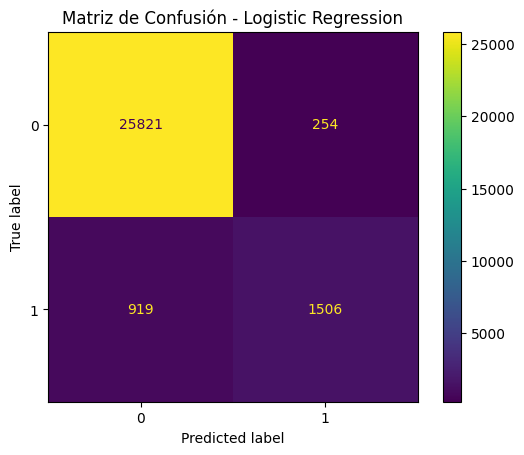

In [ ]:
# División de datos
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grilla optimizada
param_grid_lr = [
   {
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10]
}
#    {
#        'solver': ['saga'],
#        'penalty': ['l1', 'l2', 'elasticnet'],
#        'l1_ratio': [0.0, 0.5, 1.0],  # solo para elasticnet
    #     'C': [0.01, 0.1, 1, 10]
    # },
    # {
    #     'solver': ['lbfgs', 'newton-cg', 'sag'],
    #     'penalty': ['l2', 'none'],
    #     'C': [0.01, 0.1, 1, 10]
    # }
]

# Modelo base
lr = LogisticRegression(max_iter=1000)

# Grid search
grid_search_lr = GridSearchCV(lr, param_grid_lr, cv=cv, scoring='recall', n_jobs=-1, verbose=1)
grid_search_lr.fit(x_train, y_train)

# Mejor modelo
best_lr_model = grid_search_lr.best_estimator_
print("Mejores hiperparámetros:", grid_search_lr.best_params_)

# Evaluación en test
y_pred_lr = best_lr_model.predict(x_test)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_estimator(best_lr_model, x_test, y_test)
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()

**Clase 0 (Negativa):**
Muy bien clasificada:

* 99% de los negativos reales fueron detectados (recall = 0.99).

* Precisión alta (0.97): pocos falsos positivos.

* F1-score casi perfecto (0.98), lo que indica un muy buen balance entre precisión y recall.

**Clase 1 (Positiva):**
No tan bien clasificada:

* Solo el 62% de los positivos reales fueron identificados como tales (recall = 0.62).

* 38% fueron clasificados erróneamente como negativos (FN).

* Precisión es decente (0.86), indicando que cuando predice "positivo", generalmente acierta.

* F1-score = 0.72: razonable, pero muestra margen de mejora.

# SVM

Probamos 3 kernels distintos:

In [ ]:
clf = svm.SVC(kernel='linear', C=1, random_state=42)
clf.fit(x_train, y_train)
scores = cross_val_score(clf, x_train, y_train, cv=5)

print("Cross-validation scores:", scores)

Cross-validation scores: [0.94759398 0.94443609 0.94195489 0.93954887 0.94541353]


In [ ]:
clf_rbf = svm.SVC(kernel='rbf', C=1, random_state=42)
clf_rbf.fit(x_train, y_train)
scores_rbf = cross_val_score(clf_rbf, x_train, y_train, cv=5)
print("Cross-validation scores:", scores_rbf)

Cross-validation scores: [0.91496241 0.91496241 0.91496241 0.91488722 0.91488722]


In [ ]:
clf_sigmoid = svm.SVC(kernel='sigmoid', C=1, random_state=42)
clf_sigmoid.fit(x_train, y_train)
scores_sigmoid = cross_val_score(clf_sigmoid, x_train, y_train, cv=5)
print("Cross-validation scores:", scores_sigmoid)

Cross-validation scores: [0.84954887 0.85045113 0.8518797  0.84398496 0.85270677]


Podemos ver que el mejor rendimiento lo tiene el primer kernel (promedio ≈ 94.4%). Tiene buena consistencia entre las 5 particiones, lo que indica estabilidad.

# ANN con MLPClassifier

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42)
mlp_model.fit(x_train, y_train)
y_pred_mlp = mlp_model.predict(x_test)

print("Red Neuronal Artificial (ANN)")
print(classification_report(y_test, y_pred_mlp))

Red Neuronal Artificial (ANN)
              precision    recall  f1-score   support

           0       0.99      0.52      0.68     26075
           1       0.15      0.94      0.26      2425

    accuracy                           0.56     28500
   macro avg       0.57      0.73      0.47     28500
weighted avg       0.92      0.56      0.65     28500



**Clase 0 (negativos):**
* Precision muy alta (0.99): casi todas las veces que predijo 0, acertó.

* Recall muy bajo (0.52): el modelo solo encontró el 52% de los negativos reales, es decir, muchos falsos positivos.

* Esto puede indicar que el modelo sobrepredice la clase 1.

**Clase 1 (positivos):**
* Precision muy baja (0.15): cuando predice 1, solo acierta el 15% de las veces.

* Recall muy alto (0.94): casi todos los positivos reales fueron identificados, es decir, pocos falsos negativos.

* El modelo predice muchos 1s incorrectamente.



# Ensemble Learning - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x, y)
y_pred_rf = rf_model.predict(x_test)

print(" Random Forest")
print(classification_report(y_test, y_pred_rf))

📊 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26075
           1       1.00      1.00      1.00      2425

    accuracy                           1.00     28500
   macro avg       1.00      1.00      1.00     28500
weighted avg       1.00      1.00      1.00     28500



El modelo clasificó perfectamente todos los ejemplos del conjunto de prueba. Esto significa que no hubo ningún falso positivo ni falso negativo. Es decir, está sobrejustando los datos.

In [ ]:
df_test

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN
...,...,...,...,...,...,...,...,...,...,...
4995,88540,Female,23.0,0,0,never,22.77,6.6,200,NaN
4996,26701,Female,51.0,0,0,No Info,27.32,4.0,155,NaN
4997,47271,Male,79.0,0,0,No Info,23.80,6.0,126,NaN
4998,97941,Male,24.0,0,0,never,22.68,6.1,85,NaN


In [ ]:
x_test

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
25368,83855,80.0,0,0,16.72,4.0,160,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
48681,48889,37.0,0,0,27.32,5.7,85,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
34652,54966,4.0,0,0,16.74,6.6,155,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
22816,33775,62.0,0,0,27.32,6.5,145,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
33720,43192,14.0,0,0,18.73,6.5,90,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,16443,80.0,0,0,21.15,6.1,130,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
85728,62407,61.0,0,0,23.90,6.0,80,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8742,57164,70.0,0,0,23.65,4.8,155,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
31287,78172,38.0,0,0,22.14,4.0,80,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
x_train

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
85216,99424,14.0,0,0,16.83,6.5,159,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
30237,8664,80.0,0,0,25.79,4.8,100,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
47150,24235,23.0,0,0,23.77,4.5,90,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
64932,80760,38.0,0,0,27.32,6.1,200,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32697,43892,80.0,1,0,27.32,3.5,126,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70705,892,10.0,0,0,19.47,5.7,159,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4217,97553,61.0,0,0,38.92,8.2,220,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
25776,22430,67.0,0,1,36.01,8.2,300,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
69194,69839,28.0,0,0,44.26,4.0,126,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# Comparación Final de Métricas

A continuación, comparamos los distintos métodos empleados. Los resultados se almacenan en un DataFrame, se ordenan por recall y se muestran con un resaltado en los 3 mejores modelos.



In [ ]:
import pandas as pd
from IPython.display import display
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score

# Crear tabla de métricas
resultados = []

# Predict on the test set for each model
y_pred_lr = best_lr_model.predict(x_test)
# y_pred_clf = clf.predict(x_test)
y_pred_clf_rbf = clf_rbf.predict(x_test)
y_pred_clf_sigmoid = clf_sigmoid.predict(x_test)
y_pred_mlp = mlp_model.predict(x_test)
y_pred_rf = rf_model.predict(x_test)


for nombre, y_pred in zip(
    ['Logistic Regression', 'SVM_linear', 'SVM_rbf', 'SVM_sigmoid', 'ANN', 'Random Forest'],
    [y_pred_lr, y_pred_clf_rbf, y_pred_clf_sigmoid, y_pred_mlp, y_pred_rf]
):
    resultados.append({
        'Modelo': nombre,
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    })

df_resultados = pd.DataFrame(resultados)

# Ordenar por Recall y resetear índice
df_resultados_ordenado = df_resultados.sort_values(by='Recall', ascending=False).reset_index(drop=True)

# Resaltar top 3
def highlight_top_3(s):
    is_top = s.rank(method='min', ascending=False) <= 3
    return ['background-color: lightgreen' if v else '' for v in is_top]

# Aplicar estilo y mostrar
styled_df = df_resultados_ordenado.style.apply(highlight_top_3, subset=['Recall'])
display(styled_df)

C:\Users\rbarone\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Modelo,Recall,Accuracy,Precision,F1-score
0,ANN,0.999588,0.999965,1.000000,0.999794
1,SVM_sigmoid,0.936495,0.555263,0.153529,0.263809
2,Logistic Regression,0.621031,0.958842,0.855682,0.719713
3,SVM_rbf,0.078763,0.848947,0.084439,0.081502
4,SVM_linear,0.000000,0.914912,0.000000,0.000000


TEST CON SVM kernel Lineal

In [ ]:
clf

test_id = df_test['patient']

result_predected_CLF =  clf.predict(df_test_concated)

submission = pd.DataFrame(list(zip(test_id, result_predected_CLF)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission_CLF.csv", header=True, index=False)
submission

,patient,diabetes
0,49267,0
1,82280,0
2,33216,0
3,94551,0
4,43760,0
...,...,...
4995,88540,0
4996,26701,0
4997,47271,0
4998,97941,0


Finalmente, aplicamos los modelos entrenados a los datos de prueba y generamos las predicciones sobre la diabetes.

TEST CON ANN

In [ ]:
test_id = df_test['patient']

result_predected_ANN =  mlp_model.predict(df_test_concated)

submission = pd.DataFrame(list(zip(test_id, result_predected_ANN)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission_ANN.csv", header=True, index=False)
submission

,patient,diabetes
0,49267,1
1,82280,0
2,33216,1
3,94551,0
4,43760,0
...,...,...
4995,88540,1
4996,26701,1
4997,47271,1
4998,97941,0


TEST CON REGRESION LOGISTICA

In [ ]:
test_id = df_test['patient']

result_predected_RL =  best_lr_model.predict(df_test_concated)

submission = pd.DataFrame(list(zip(test_id, result_predected_RL)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission_regresion.csv", header=True, index=False)
submission

,patient,diabetes
0,49267,0
1,82280,0
2,33216,0
3,94551,0
4,43760,0
...,...,...
4995,88540,0
4996,26701,0
4997,47271,0
4998,97941,0


TEST CON RANDOM FOREST

In [ ]:
test_id = df_test['patient']

result_predected =  rf_model.predict(df_test_concated)

submission = pd.DataFrame(list(zip(test_id, result_predected)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission.csv", header=True, index=False)

In [ ]:
submission

,patient,diabetes
0,49267,0
1,82280,0
2,33216,0
3,94551,0
4,43760,0
...,...,...
4995,88540,0
4996,26701,0
4997,47271,0
4998,97941,0
